## Load packages

In [1]:
import numpy as np
import time
import random 
import math

from LatticeTools import ReadLatticeParticle
from LatticeTools import DesignLEL
from LatticeTools import ParticleRepresentation
from LatticeTools import LELrepresentation
from LatticeTools import plot_a_system
from SideClasses import SideFunctions as SF

import matplotlib
from matplotlib import cm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
from matplotlib import colors as colors_matplotlib

## Load files 

In [2]:
# The tools to read lattices and plot images 
directoryLattice = '/Users/lkoehler/Documents/SelfAssembly2/Lattice/'
Triangular = ReadLatticeParticle('Triangular', directoryLattice)  
LR = LELrepresentation(Triangular, 1)
designs = DesignLEL(Triangular, 1)

# The data of simulation in the dense and dilute system 
name0 = '240531RandomOne'
nameDense = '240627RandomOneDense'

rootDirectoryData = '/Users/lkoehler/Documents/SelfAssembly2/Saved/DataPRX/'#'/Users/lkoehler/Documents/SelfAssembly2/Saved/'
directroyData = rootDirectoryData+name0+'/'
directroyDataDense = rootDirectoryData+nameDense+'/'
directoryImage = rootDirectoryData+name0+'/ImagesData/' 
directoryImagePNG = rootDirectoryData+name0+'/ImagesPNG/'

all_data = SF.fileToPickle(directroyData+'all_data')
all_data_dense = SF.fileToPickle(directroyDataDense+'all_data')

# The calculation of the "mean field" system used to compute frustration 
all_data_frustration = SF.fileToPickle(directroyData+'all_data_frustration')

# The label of the data
labels_unclassified = SF.fileToPickle(directroyData+'labels_unclassified')

# Categories names corresponding to the integers stored in labels
categories_names = ['monomer', 'oligomer', 'gel', 'polycrystal','fiber',
                    'sponge', 'crystal', 'liquid']#, 'idk']



## Function to plot one system 

In [3]:
def plot_image_random(key, dense=False, axes = None):
    affinity, anisotropy, index= key
    if not dense:
        name = "240531RandomOne"
        directoryImage =rootDirectoryData+name+'/ImagesData/'   
        
    else :
        name = "240627RandomOneDense"
        directoryImage =rootDirectoryData+name+'/ImagesData/'
        
    name+="_Af_"+str(int(affinity*10)).zfill(3)
    name+="_Ani_"+str(int(anisotropy*10)).zfill(3)
    
    data_image = SF.fileToPickle(directoryImage+name)[index]
    plot_a_system(data_image, axes=axes)
    

## Look at one system - choose the system

The keys to access one data is (mu, sigma, index) where mu and sigma are the average and standard deviation of which the interaction map was drawn from, and index is an integer *dividable by five*.

In [28]:
mu, sigma, index = 4, 9, 200
key = (mu, sigma, index)
my_data = all_data[key]
my_data_MF = all_data_frustration[key]

## Look at one system - the image and category

This aggregate was classified as fiber


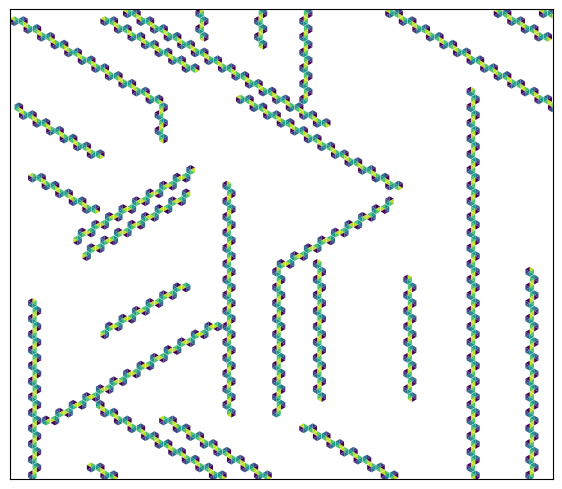

In [5]:
plot_image_random(key, dense=False)
print("This aggregate was classified as "+categories_names[labels_unclassified[key]])

## Look at one system - the interaction map and density map 

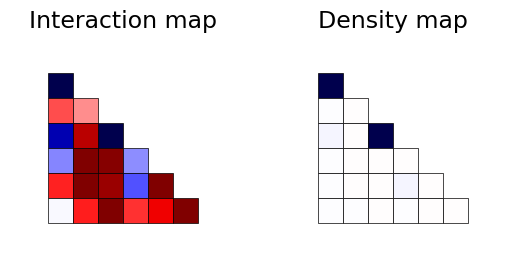

In [7]:
# Interaction map - this is a 21 dimensional vector
LEL = my_data["LEL"]
# Density map - this is a 21 dimensional vector
c = my_data["c"]

f,axes=plt.subplots(1,2)
LR.plot_matrix(LEL, vectorIsLEL=True, fullMatrix=False,axes=axes[0])
LR.plot_matrix(c, vectorIsLEL=False, fullMatrix=False,axes=axes[1])
axes[0].set_title("Interaction map",fontsize=17)
axes[1].set_title("Density map",fontsize=17);

Convert the indices of the LEL and the c vector into whichever indexing you want by printing for each index of the LEL to which pair of orientations (o1,o2) of the particles it corresponds to

In [ ]:
for s in range(1,28):
    print("s="+str(s)+" (o1,o2)="+str(Triangular.state_to_particle_orientation[s]))

s=1 (o1,o2)=(0, 1)
s=2 (o1,o2)=(0, 2)
s=3 (o1,o2)=(0, 3)
s=4 (o1,o2)=(0, 4)
s=5 (o1,o2)=(0, 5)
s=6 (o1,o2)=(0, 6)
s=7 (o1,o2)=(1, 1)
s=8 (o1,o2)=(1, 2)
s=9 (o1,o2)=(1, 3)
s=10 (o1,o2)=(1, 4)
s=11 (o1,o2)=(1, 5)
s=12 (o1,o2)=(1, 6)
s=13 (o1,o2)=(2, 1)
s=14 (o1,o2)=(2, 2)
s=15 (o1,o2)=(2, 3)
s=16 (o1,o2)=(2, 4)
s=17 (o1,o2)=(2, 5)
s=18 (o1,o2)=(2, 6)
s=19 (o1,o2)=(3, 1)
s=20 (o1,o2)=(3, 2)
s=21 (o1,o2)=(3, 3)


Show an image of the corresponding pair of paricle for one chose structure

p1,p2,o1,o2,edge 0 0 1 6 1
Axes(0.125,0.11;0.775x0.77) arrowed


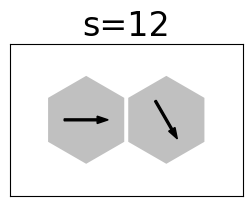

In [17]:
structure=12
Triangular.show_structure(structure,twoParticlesStructures=True);

## Look at the corresponding dense system

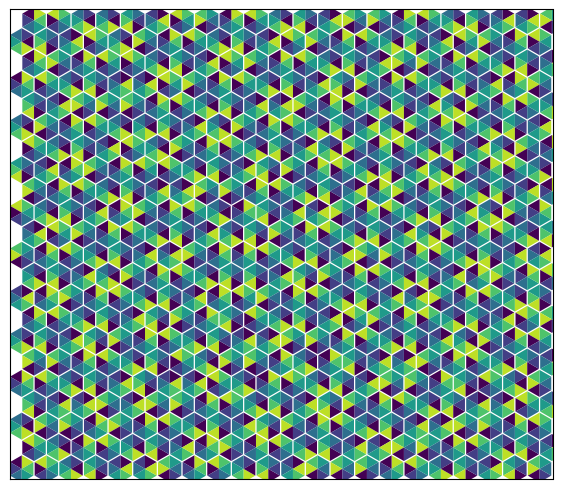

In [19]:
plot_image_random(key, dense=True)

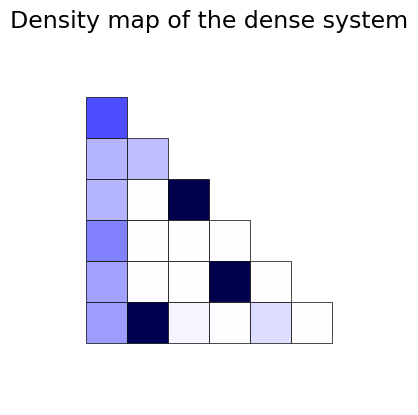

In [27]:
# Density map - this is a 21 dimensional vector
c_dense = my_data["c_dense"]

f,axes=plt.subplots(1,1)
LR.plot_matrix(c_dense, vectorIsLEL=False, fullMatrix=False,axes=axes)
axes.set_title("Density map of the dense system",fontsize=17);

### Look at the mean field density map 

In [32]:
c_boltzmann = my_data_MF["c_boltzmann"]
c_boltzmann_dense = my_data_MF["c_boltzmann_dense"]

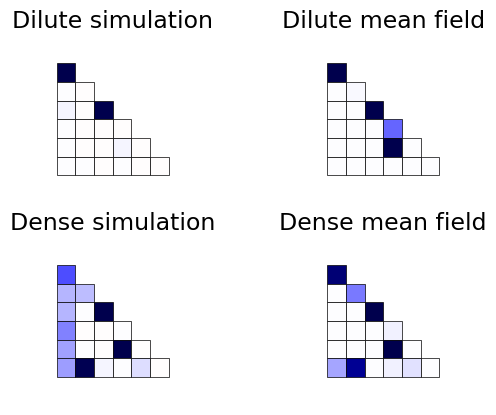

In [34]:
f, axes = plt.subplots(2,2)
LR.plot_matrix(c, vectorIsLEL=False, fullMatrix=False,axes=axes[0,0])
axes[0,0].set_title("Dilute simulation",fontsize=17);
LR.plot_matrix(c_dense, vectorIsLEL=False, fullMatrix=False,axes=axes[1,0])
axes[1,0].set_title("Dense simulation",fontsize=17);
LR.plot_matrix(c_boltzmann, vectorIsLEL=False, fullMatrix=False,axes=axes[0,1])
axes[0,1].set_title("Dilute mean field",fontsize=17);
LR.plot_matrix(c_boltzmann_dense, vectorIsLEL=False, fullMatrix=False,axes=axes[1,1])
axes[1,1].set_title("Dense mean field",fontsize=17);